# Dataset Creation

In this notebook, we will create the chromatin dataset to deconvolve. This will involve multiple steps. We have many of these pieces already written in other notebooks. So this is a notebook to consolidate and bring a clear workflow to the dataset.


*Steps:*
1. Define gene set
2. Copy number normalization, as defined by Yulong Li
3. +1 Nucleosome alignment
4. Partition lengths by nucleosome, mid-size, small fragment length
5. Partition genomic position by half-nucleosome length.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
# For now we will define our gene set from a previous run
# This will give us chromosome, TSS, strand information

genes = pd.read_csv('data/reference_data/geneset_nondub_w_prom_genebodies.csv')
genes.head(2)


,orf_name,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end
0,YAL068C,PAU8,1,gene,1807,2169,-,Verified,362,2169,NaN,NaN,2169.0,2469.0,1669.0,2169.0
1,YAL067W-A,YAL067W-A,1,gene,2480,2707,+,Uncharacterized,227,2480,NaN,NaN,2180.0,2480.0,2480.0,2980.0


In [5]:
# Copy number normalization

# To correct for replication-dependent 

""" 

via Yulong Li, 2021

DNA copy number variation throughout the cell cycle for a given chromosomal location, 

the RPKM of all MNase-seq reads for a 1001 bp window centered at the given position
was calculated for each time point, 

the ratio of this RPKM to the RPKM of the
α-factor time point (G1) 

was considered to be the copy number. 

For each time point, 
the nucleosome score for any chromosomal location was normalized by its copy number.
"""


# In other words, the number reads was normalized by the 0 timepoint. Because at 0 time,
# cell should be in G1. 

# How does this differ than normalizing by the fragment length of the lowest
# sampled timepoint...

# Copy number seems to be important to normalize under. To ensure the number of reads match
# single copy of DNA.

# Separately, may we can then normalize by length? Or should we skip that...

# -----------------

# This may be a question to set aside


# -------------------


In [7]:
# Let's do +1 Nucleosome alignment

from cc_src.chromatin_grid_compute import ChromatinGrid

chromatin_gridder = ChromatinGrid()

In [9]:
chromatin_gridder.set_gene('CLB2')
chromatin_gridder.create_bins_per_sample()


In [49]:
# First we will need the nucleosome length fragments, 
# we defined these previously in another notebook: "Chromatin Length Distribution"

plus_one = chromatin_gridder.find_max_plusOne_pos()
print(f"Computed the plus one location as: {plus_one}")

Computed the plus one location as: 771279


In [51]:
# Now we want to line up our gridding to this position.

# Then redefine our grid as half widths and the len spans we previously defined.
chromatin_gridder.set_gene('CLB2')
chromatin_gridder.create_bins_per_all_sample()


The histogram shape for the 2000 bp window around the TSS: (3, 20)
The shape for the middle 10 bins (1000 bp around the TSS): (3, 10)


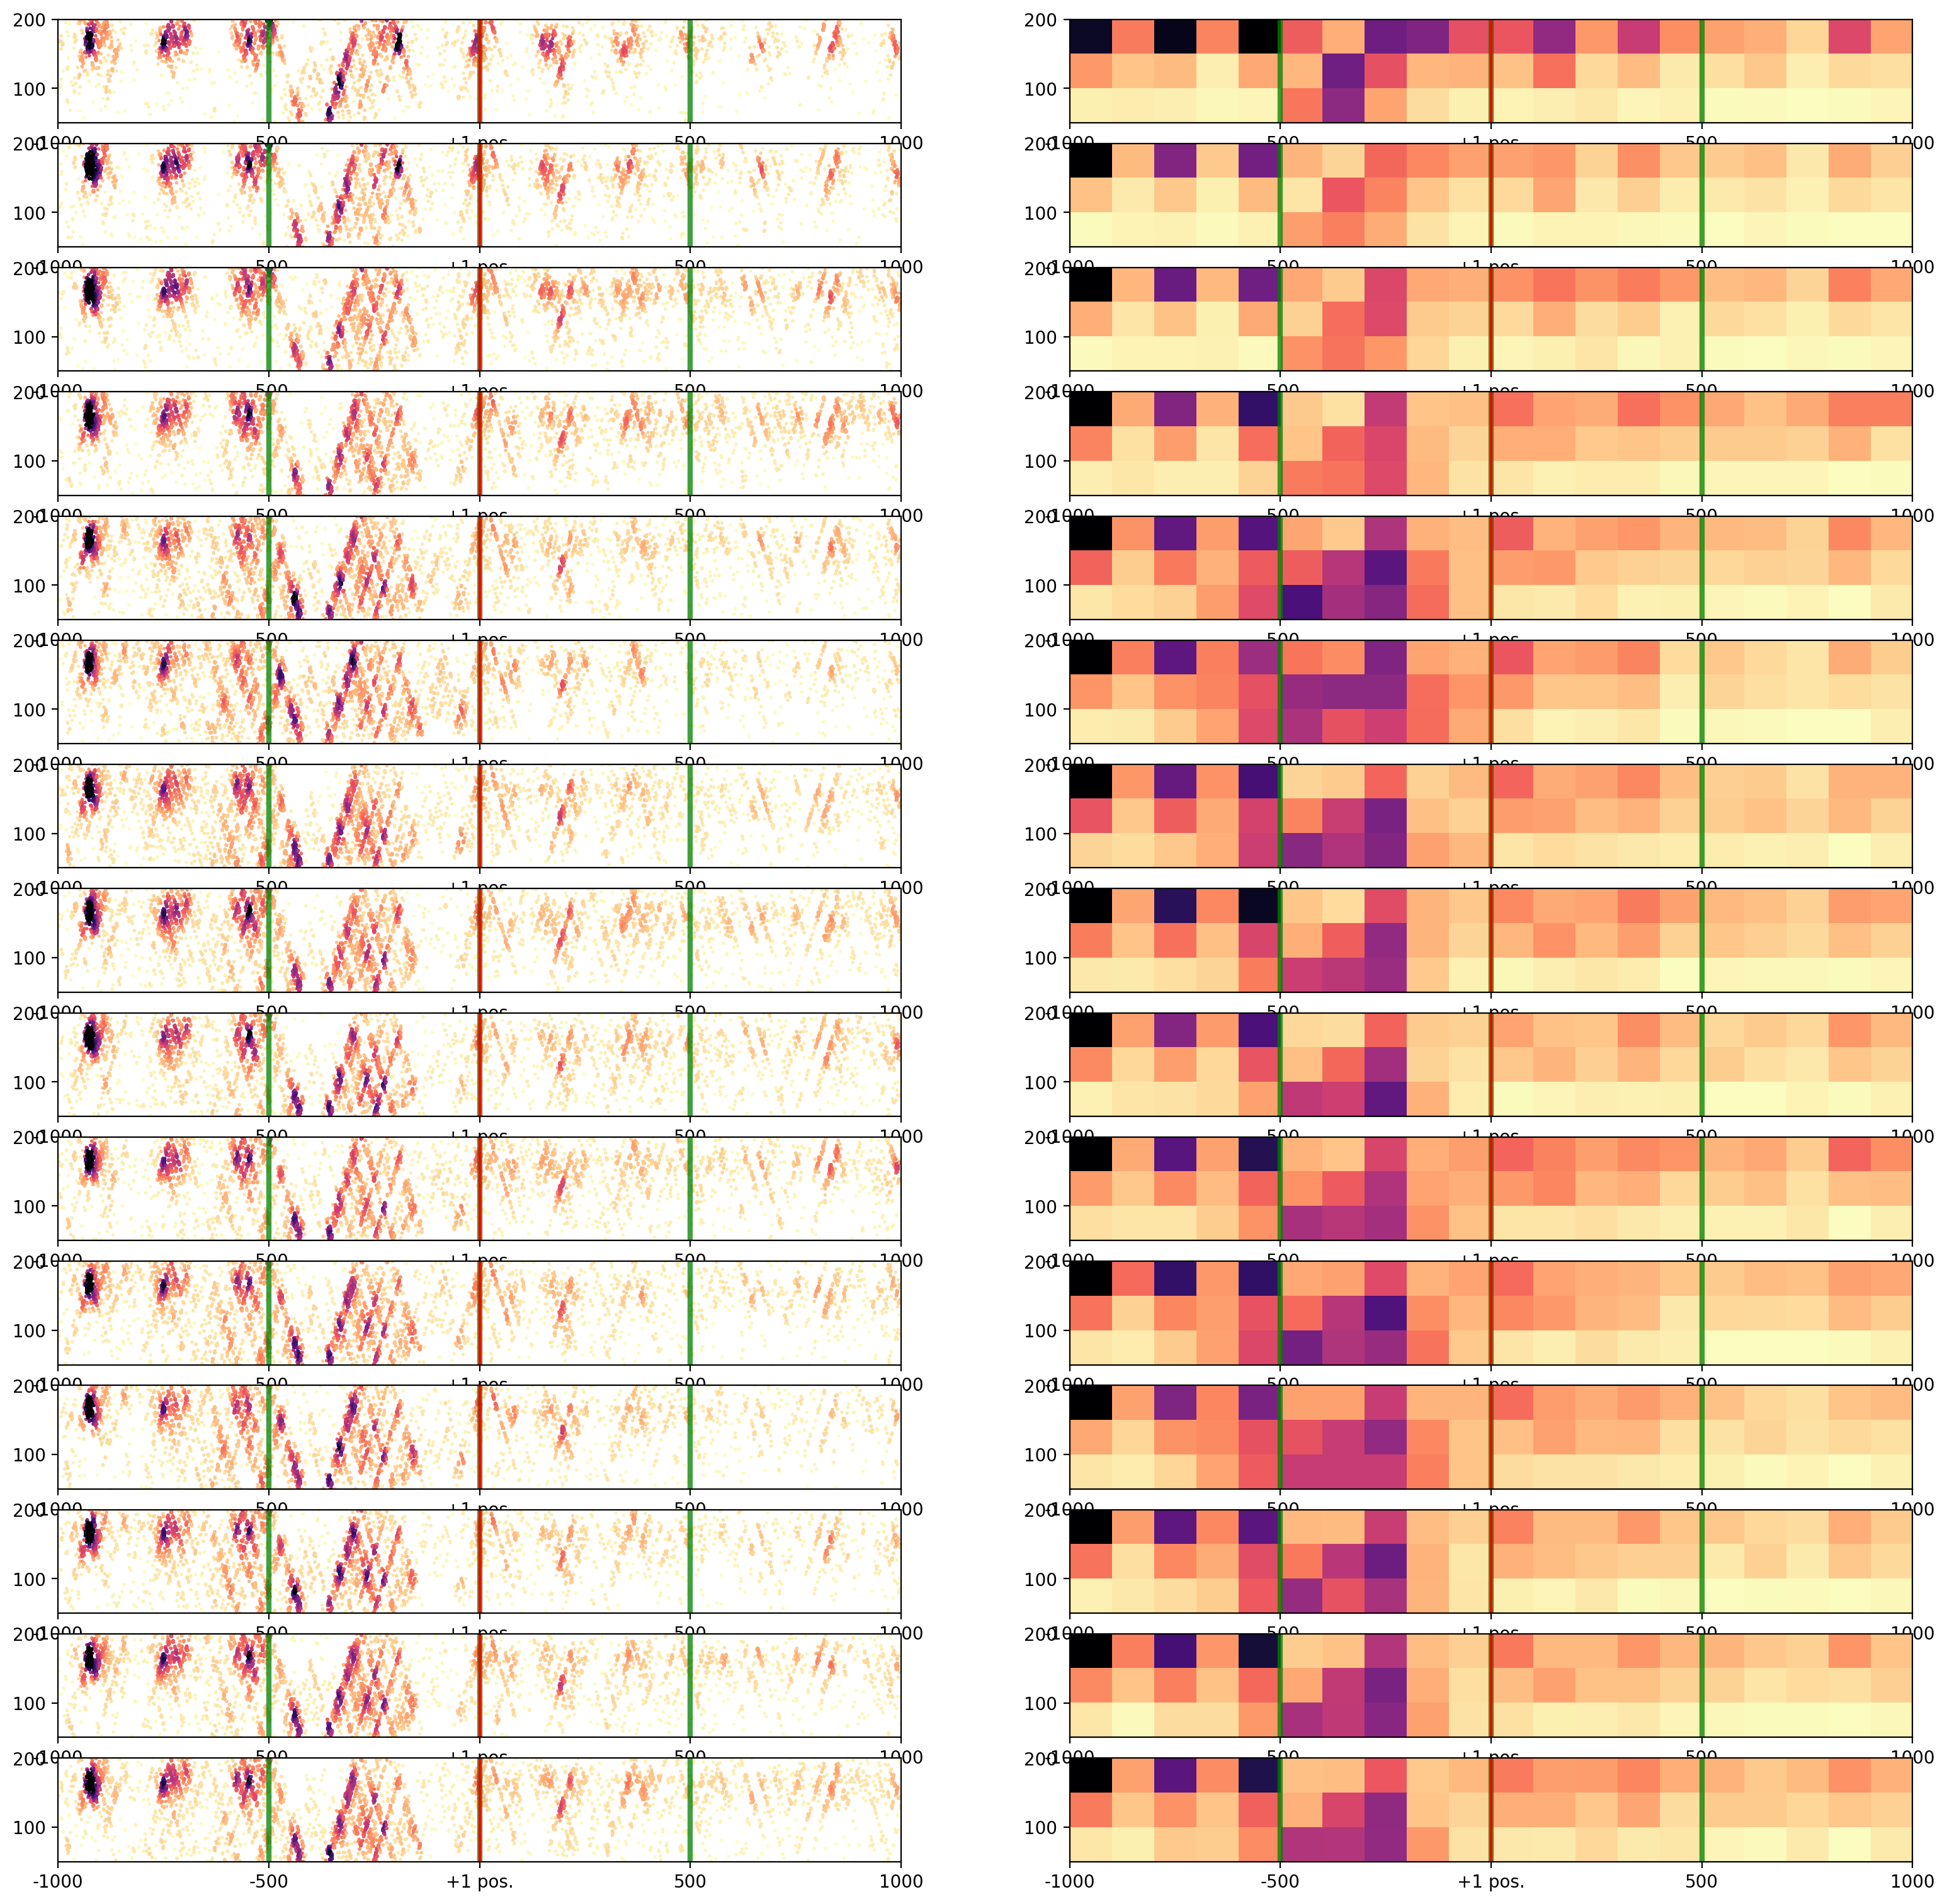

In [60]:
chromatin_gridder.plot_raw_and_grid()


In [62]:

# Now we want to define the horizontal grid as starting with 
# the center as a nucleosome position
# then 80 bp bin sizes from therein.

# 6 bins forward, 4 bins back
# 6 will capture the first three nucleosomes
# the back 3 may include extra things, but we can filter that out later (?)

# If we do this asymmetricaly, we should flip the dataset.
# That's 11 bins

#
#
# |-- 3 bins --|-- +1 --|-- 6 bins --|
#   promoter               gene body
#   280 bp       80 bp      480 bins
#
#
#      -310     |      +520
#       |      +1       |
#
